# Task 1 - Student Score Prediction

Predicting students' exam scores from the hours they study using linear regression.
Dataset: Student Performance Factors from Kaggle (6607 students, 20 columns).

## 1. Loading the data


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("StudentPerformanceFactors.csv")
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


## 2. Understanding the data
Size of the dataset, column types, and summary statistics.

In [7]:
df.shape

(6607, 20)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [9]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


## 3. Data cleaning
Check for missing values, duplicate rows and impossible values.

In [10]:
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df[df["Exam_Score"] > 100]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,101


**Cleaning decisions**:
3 columns have around 1% missing values, so I filled them with the most common value
instead of deleting the rows. There are no duplicates. One student has a score of 101
which is not possible, so I removed that row.

In [13]:
for col in ["Teacher_Quality", "Parental_Education_Level", "Distance_from_Home"]:
    most_common = df[col].mode()[0]
    df[col] = df[col].fillna(most_common)
    print(col, "-> filled with", most_common)

df = df[df["Exam_Score"] <= 100]

print("Missing values left:", df.isnull().sum().sum())
print("Max exam score:", df["Exam_Score"].max())
print("Rows now:", len(df))

Teacher_Quality -> filled with Medium
Parental_Education_Level -> filled with High School
Distance_from_Home -> filled with Near
Missing values left: 0
Max exam score: 100
Rows now: 6606


## 4. Visualisation

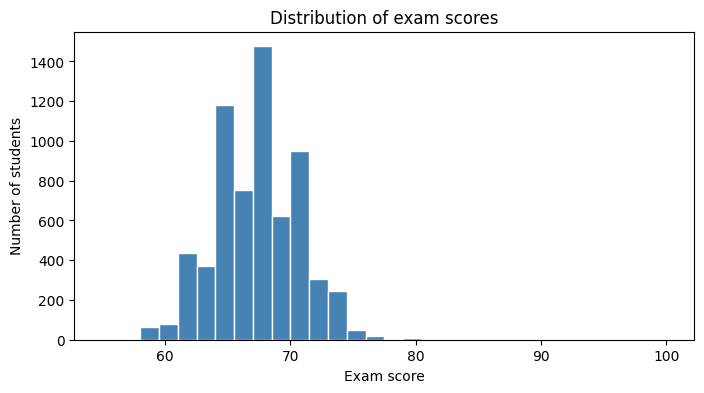

In [14]:
plt.figure(figsize=(8, 4))
plt.hist(df["Exam_Score"], bins=30, color="steelblue", edgecolor="white")
plt.title("Distribution of exam scores")
plt.xlabel("Exam score")
plt.ylabel("Number of students")
plt.show()

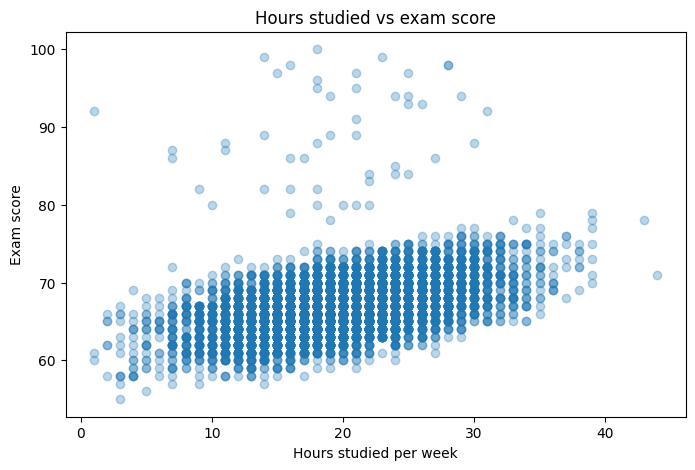

In [15]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Hours_Studied"], df["Exam_Score"], alpha=0.3)
plt.title("Hours studied vs exam score")
plt.xlabel("Hours studied per week")
plt.ylabel("Exam score")
plt.show()

Students who study more tend to get higher scores. The correlation is 0.45 which is a
moderate positive relationship.

In [16]:
df["Hours_Studied"].corr(df["Exam_Score"])

np.float64(0.44651362278980544)

## 5. Train/test split
80% training and 20% testing.

In [17]:
from sklearn.model_selection import train_test_split

X = df[["Hours_Studied"]]
y = df["Exam_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training students:", len(X_train))
print("Test students:", len(X_test))

Training students: 5284
Test students: 1322


## 6. Linear regression model
Simple linear regression learns a straight line: score = slope × hours + intercept.

In [18]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: 0.28571318331248846
Intercept: 61.54600994601386


In [19]:
examples = pd.DataFrame({"Hours_Studied": [10, 20, 30]})
model.predict(examples)

array([64.40314178, 67.26027361, 70.11740545])

## 7. Evaluation
MAE is the average error in exam points, RMSE is similar but punishes big errors more,
and R2 shows how much of the score the model can explain (1 is perfect).

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.3f}")

MAE:  2.42
RMSE: 3.16
R²:   0.247


### Visualising the predictions

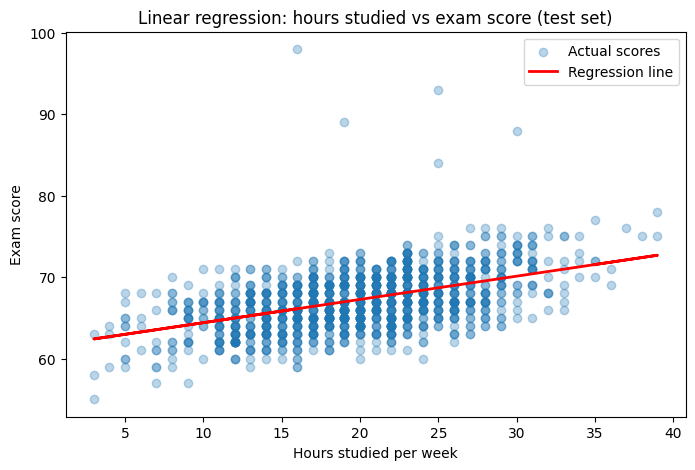

In [21]:
plt.figure(figsize=(8, 5))
plt.scatter(X_test["Hours_Studied"], y_test, alpha=0.3, label="Actual scores")
plt.plot(X_test["Hours_Studied"], y_pred, color="red", linewidth=2, label="Regression line")
plt.title("Linear regression: hours studied vs exam score (test set)")
plt.xlabel("Hours studied per week")
plt.ylabel("Exam score")
plt.legend()
plt.show()

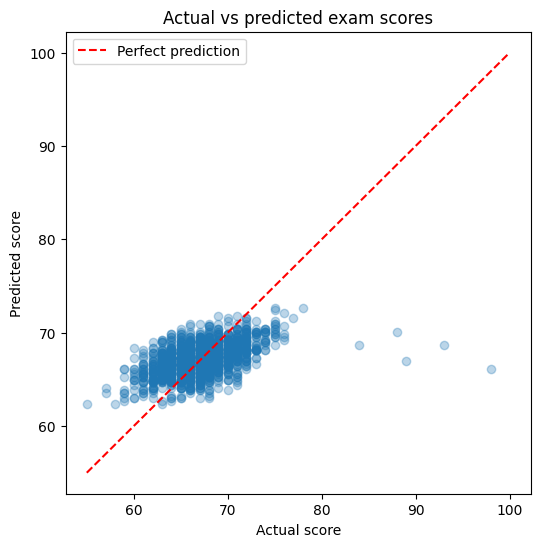

In [22]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([55, 100], [55, 100], color="red", linestyle="--", label="Perfect prediction")
plt.title("Actual vs predicted exam scores")
plt.xlabel("Actual score")
plt.ylabel("Predicted score")
plt.legend()
plt.show()

## 8. Bonus: polynomial regression
Test whether a curve (degree 2–4) fits better than a straight line.

In [23]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

results = []
for degree in [1, 2, 3, 4]:
    poly_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    poly_model.fit(X_train, y_train)
    pred = poly_model.predict(X_test)
    results.append({
        "Degree": degree,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": mean_squared_error(y_test, pred) ** 0.5,
        "R²": r2_score(y_test, pred),
    })

pd.DataFrame(results).round(4)

,Degree,MAE,RMSE,R²
0,1,2.4190,3.1559,0.2469
1,2,2.4151,3.1538,0.2479
2,3,2.4172,3.1577,0.2460
3,4,2.4187,3.1591,0.2453


## 9. Bonus: feature combinations
Add features one at a time, including sleep, and compare the results.

In [25]:
feature_sets = {
    "Hours only": ["Hours_Studied"],
    "+ Attendance": ["Hours_Studied", "Attendance"],
    "+ Previous scores": ["Hours_Studied", "Attendance", "Previous_Scores"],
    "+ Tutoring": ["Hours_Studied", "Attendance", "Previous_Scores", "Tutoring_Sessions"],
    "+ Sleep": ["Hours_Studied", "Attendance", "Previous_Scores", "Tutoring_Sessions", "Sleep_Hours"],
}

rows = []
for name, cols in feature_sets.items():
    X_tr, X_te, y_tr, y_te = train_test_split(df[cols], y, test_size=0.2, random_state=42)
    m = LinearRegression().fit(X_tr, y_tr)
    p = m.predict(X_te)
    rows.append({"Features": name, "MAE": mean_absolute_error(y_te, p), "R²": r2_score(y_te, p)})

pd.DataFrame(rows).round(3)

,Features,MAE,R²
0,Hours only,2.419,0.247
1,+ Attendance,1.430,0.622
2,+ Previous scores,1.330,0.655
3,+ Tutoring,1.253,0.681
4,+ Sleep,1.253,0.681


## Conclusion

I cleaned the data by filling the missing values in 3 columns with the most common value
and removing one row where the exam score was 101, which is not possible.
After cleaning there were 6606 students.

The linear regression model using only hours studied gave:
score = 0.286 * hours + 61.55

This means every extra hour of study adds around 0.29 points to the score.

On the test set the model got MAE = 2.42, RMSE = 3.16 and R2 = 0.247.
So the predictions are off by about 2.4 points on average, and hours studied
only explains around 25% of the exam score.

Polynomial regression (degree 2 to 4) did not improve the results,
so a straight line is enough for this data.

When I added more features the model got much better:
- adding Attendance increased R2 from 0.25 to 0.62
- adding Previous Scores and Tutoring increased it to 0.68
- adding Sleep did not change anything

So attendance is the most important factor after study hours,
and sleep does not help predict the score in this dataset.
